![EU/US Sanctions Cartoon](../img/sanctions1.jpg)

# EDA Task 1: Sanctions Event Study



### **Problem**
Quantifies the impact of specific sanctions events on:  
- MOEX Index (Russian equity market)  
- USD/RUB exchange rate (ruble depreciation)  
- Urals–Brent discount (energy export penalty)  


### **Standard Event-Study Methodology**

Normal return model (market model via OLS)  
    $$r_{i,t} = \alpha_i + \beta_i\  r_{brent,t} + ε_{i,t}$$

Constant return model:
    $$r_{i,t} = \alpha_i + ε_{i,t}$$
 
$ε_{i,t} \sim N(0, \sigma^2_\epsilon)$   
    

Abnormal Returns (AR)
    $$AR_{i,t} = r_{i,t}  −  (\alpha_i + \beta_i \cdot r_{brent,t})$$
    $$AR_{i,t} = r_{i,t}  −  \alpha_i$$
 
Cumulative Abnormal Return (CAR)  
    $$CAR_i([t_1, t_2]) = \sum_{t=t_1}^{t_2} AR_{i,t}$$


Significance Test   
    Under $H_0$ (no event effect), ARs are i.i.d. $N(0, \sigma^2_\epsilon)$.  
    The test statistic for CAR over n days:  
        $$t = CAR / (\sigma_\epsilon \cdot \sqrt{n})$$
    where $\sigma_\epsilon$ is the residual std from the estimation window OLS.  
    p-values from two-tailed t-distribution with $(n_{est} − 2)$ df.



## **1. Configuration and data import**

In [2]:
# Libraries importing 
import numbers
import numpy as np
import scipy as scp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

from IPython.display import display, HTML, Markdown, Image, JSON, clear_output
import warnings
 
warnings.filterwarnings('ignore')

# Configuration
%matplotlib inline
pd.set_option('display.max_columns', 50)

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=[
   '#9b59b6', '#2ecc71', 
   '#e74c3c', '#3498db', 
   '#f39c12', "#09ecf8",
   "#f9ec37",
])
plt.style.use(['seaborn-v0_8-whitegrid', 
               'seaborn-v0_8-paper'])
plt.style.use('ggplot')

plt.rcParams.update({
    # Figure
    'figure.dpi':           150,
    'figure.facecolor':     'white',
    # Axes
    'axes.titlesize':       16,
    'axes.labelsize':       16,
    'axes.grid':            True,
    'axes.spines.top':      False,
    'axes.spines.right':    False,
    # Lines
    'lines.linewidth':      2,
    'lines.markersize':     8,
    # Font
    'font.family':          'sans-serif',
    'font.size':            14,
    # Legend
    'legend.fontsize':      14,
    'legend.frameon':       False,
    # Ticks
    'xtick.labelsize':      14,
    'ytick.labelsize':      14,
    'xtick.direction':      'out',
    'ytick.direction':      'out',
    # Saving
    'savefig.dpi':          200,
    'savefig.bbox':         'tight',
})


In [3]:
# ----------------------------------------------------------------
# - LOAD DATASETS TO DATAFRAMES 
# ----------------------------------------------------------------

print("Start loading datasets...\n")

sanctions = pd.read_csv("../data/processed_data/sanctions.csv", parse_dates=['date'])
daily = pd.read_csv("../data/processed_data/daily.csv", parse_dates=['date'])


print("All datasets loaded successfully!")

Start loading datasets...

All datasets loaded successfully!


## **B. Sanctions Event Study Analysis**

In [4]:
# - get values of desired columns
arr = {c: daily[c].values for c in ['moex_ret','rub_ret','brent_ret','urals_disc_chg']}
dates_arr = daily['date'].values
tidx_arr  = daily['t_idx'].values

In [5]:
# -----------------------------------------------------------------------
# - 1. Window parameters
# -----------------------------------------------------------------------
EVT_WIN_PRE, EVT_WIN_POST = -10, 25
EST_WIN_POST = -15
TARGET_NUM = 150
MIN_NUM = 60
# Estimated CAR window:
CAR_WINDOWS = {
    'W_m2_5': (-2, 5),
    'W_m2_10': (-2, 10),
    'W_m2_25': (-2, 25),
    'W_m5_5': (-5, 5),
    'W_m5_10': (-5, 10),
    'W_m5_25': (-5, 25),
    'W_m10_5': (-10, 5),
    'W_m10_10': (-10, 10),
    'W_m10_25': (-10, 25),
}

In [6]:
# -----------------------------------------------------------------------
# - 1. Build trading date index: map sanction dates to trading dates
# -----------------------------------------------------------------------

N=len(daily)
def next_trading_date(d):
    pos = np.searchsorted(dates_arr, np.datetime64(d,'D'))
    return min(pos, N-1)

sanctions['t_idx'] = sanctions['date'].apply(next_trading_date)

In [7]:
# -----------------------------------------------------------------------
# - 2. Event clustering (GAP = EVENT WINDOW WIDTH)
# -----------------------------------------------------------------------
GAP = abs(EVT_WIN_PRE) + abs(EVT_WIN_POST) 
sanctions = sanctions.sort_values('t_idx').reset_index(drop=True)
cid, cur = [0], 0
for i in range(1, len(sanctions)):
    if sanctions.loc[i,'t_idx'] - sanctions.loc[i-1,'t_idx'] <= GAP:
        cid.append(cur)
    else:
        cur += 1
        cid.append(cur)
sanctions['cluster_id'] = cid

clusters = sanctions.groupby('cluster_id').agg(
    n_events = ('event_id', 'count'),
    start_idx = ('t_idx', 'min'),
    end_idx = ('t_idx', 'max'),
    start_date = ('date', 'min'),
    end_date = ('date', 'max'),
    severity_sum = ('severity_score', 'sum'),
    severity_max = ('severity_score', 'max')
)
print(f"\nClustering (GAP={GAP}): {len(sanctions)} raw events → {len(clusters)} episodes \n")
print(clusters['n_events'].value_counts().sort_index().rename('episodes_with_N_events'))
clusters=clusters.reset_index()
clusters.to_csv("../data/results/clusters.csv")
#display(clusters)
display(sanctions.groupby('wave').agg(
    n_events = ('cluster_id', 'nunique')))



Clustering (GAP=35): 60 raw events → 25 episodes 

n_events
1     15
2      5
3      2
4      1
6      1
19     1
Name: episodes_with_N_events, dtype: int64


,n_events
wave,
wave_1_crimea,11
wave_2_ukraine,3
wave_3_secondary,11


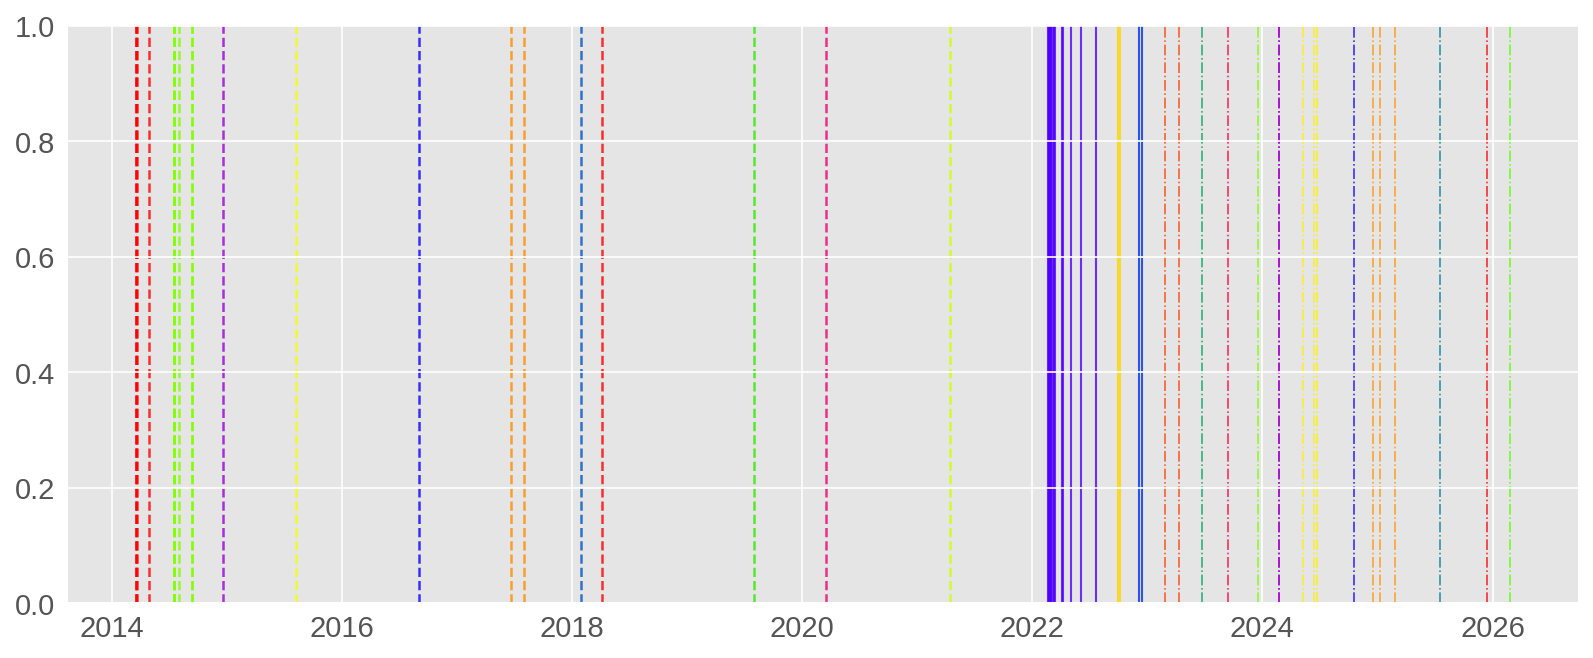

In [8]:
# plot
fig, ax = plt.subplots(figsize=(13,5))
wave_colors = {
    'wave_1_crimea': ('--', 1.2),
    'wave_2_ukraine': ('-', 1.0),
    'wave_3_secondary': ('-.', 0.8)
}
nc = sanctions['cluster_id'].nunique()
cmap = plt.cm.prism
colors = [cmap(i / (nc-1)) for i in range(nc)]
cluster_colors = {}
for i, c in enumerate(sanctions['cluster_id'].unique().tolist()):
    cluster_colors[c] = colors[i]
for id, r in sanctions.iterrows():
    ax.axvline(r['date'], 
               ls=wave_colors[r['wave']][0], 
               color=cluster_colors[r['cluster_id']], 
               alpha=0.8, lw=wave_colors[r['wave']][1], zorder=0)
#for id, r in clusters.iterrows():
#    ax.axvspan(r['start_date'], r['end_date'], alpha=0.3, color=cluster_colors[r['cluster_id']])
plt.savefig('../output/task1_event_clustering.png', bbox_inches='tight')

In [9]:
# -----------------------------------------------------------------------
# - 3. Contamination mask
# -----------------------------------------------------------------------
BUF_PRE, BUF_POST = 0, 0 # exactly in the event window
contaminated = np.zeros(N, dtype=bool)
for _, row in clusters.iterrows():
    lo = max(0, row.start_idx - BUF_PRE)
    hi = max(0, row.end_idx + BUF_POST + 1)
    contaminated[lo:hi] = True

In [10]:
# -----------------------------------------------------------------------
# - 4. Estimation window
# -----------------------------------------------------------------------
def get_clean_estimation(start_idx):
    idxs = []
    pos = start_idx + EST_WIN_POST
    while pos >= 0 and len(idxs) < TARGET_NUM:
        if not contaminated[pos]:
            idxs.append(pos)
        pos -= 1
    ok = len(idxs) >= MIN_NUM
    return np.array(sorted(idxs)), ok


In [11]:
# -----------------------------------------------------------------------
# - 5. Models helpers
# -----------------------------------------------------------------------
def constant_mean_model(y_vals):
    """Constant mean model for MOEX anc RUB returns"""
    mask = ~np.isnan(y_vals)
    y = y_vals[mask]
    mu = y.mean()
    sigma = y.std(ddof=1)
    return mu, sigma, len(y)

def market_model(y_vals, x_vals):
    """OLS for normal model """
    mask = ~np.isnan(y_vals) & ~np.isnan(x_vals)
    y, x = y_vals[mask], x_vals[mask]
    x = sm.add_constant(x)  # Add constant term (intercept)
    ols_res = sm.OLS(y, x).fit()
    alpha, beta = ols_res.params[0], ols_res.params[1]
    r2, r2_adjusted = ols_res.rsquared, ols_res.rsquared_adj
    pvals = ols_res.pvalues
    y_hat = x @ ols_res.params
    sigma = (y - y_hat).std(ddof=2)
    res = {
        'alpha': alpha,
        'beta': beta,
        'sigma': sigma,
        'r2': r2,
        'r2_adj': r2_adjusted,
        'pvals': pvals,
        'n_est': len(y)
    }
    return res    

In [12]:
# -----------------------------------------------------------------------
# - 5. CAR windows and run model evaluation helper
# -----------------------------------------------------------------------

def run_eps(y_col, x_col, model_type, start_idx, end_idx):
    est_idx, ok = get_clean_estimation(start_idx)
    if not ok:
        return None
    L1 = len(est_idx) # leng of estimation windows
    yv = arr[y_col][est_idx]
    
    # fit the model
    if model_type == 'constant_mean':
        mu, sigma, n_est = constant_mean_model(yv)
        alpha, beta, r2, r2_adjusted = mu, 0.0, np.nan, np.nan
        pvals = [0, 0]
    else:
        xv = arr[x_col][est_idx]
        res = market_model(yv, xv)
        alpha = res['alpha']
        beta = res['beta']
        sigma = res['sigma']
        r2 = res['r2']
        r2_adjusted = res['r2_adj']
        n_est = res['n_est']
        pvals = res['pvals']
       
    # event window
    lo = max(0, start_idx)
    hi = min(N-1, end_idx)
    rel = tidx_arr[lo:hi+1] - start_idx # relative to start windows
    yw = arr[y_col][lo:hi+1]
    # abnormal return evaluation
    if model_type == 'constant_mean':
        expected = np.full_like(yw, alpha)
    else:
        xw = arr[x_col][lo:hi+1]
        expected = alpha + beta*xw
    AR = yw - expected
    output = {
        'model': model_type,
        'alpha': alpha,
        'beta': beta,
        'sigma': sigma,
        'n_est': n_est,
        'r2': r2,
        'r2_adjusted': r2_adjusted,
        'p_values': pvals
    } 
    # calculate CAR
    for w, (a, b) in CAR_WINDOWS.items():
        m = (rel>=a) & (rel<=b)
        ar_w = AR[m]
        ar_w = ar_w[~np.isnan(ar_w)]
        L = len(ar_w)
        car = ar_w.sum() if L>0 else np.nan
        se = sigma*np.sqrt(L*(1+(L/L1))) if (L>0 and not np.isnan(sigma)) else np.nan
        tstat = car/se if (se and se>0) else np.nan
        pval = 2*(1-stats.norm.cdf(abs(tstat))) if not np.isnan(tstat) else np.nan
        output[f'{w}_CAR'] = car
        output[f'{w}_L'] = L
        output[f'{w}_t'] = tstat
        output[f'{w}_pval'] = pval
    #output['_rel'] = rel
    #output['_AR'] = AR
    return output

In [13]:
# -----------------------------------------------------------------------
# - 6. Run model evaluation for each cluster
# -----------------------------------------------------------------------
TARGETS = [ # (column, model_type, label)
    ('moex_ret', 'constant_mean', 'MOEX'),
    ('rub_ret', 'constant_mean', 'USD/RUB'),
    ('urals_disc_chg', 'market_model', 'Urals disc.')
]
xc = 'brent_ret' # independent variable for market model
rows = []
for _, c in clusters.iterrows(): # loop for each cluster
    for yc, mtype, label in TARGETS: # loop for each target
        r=run_eps(yc, xc, mtype, c.start_idx, c.end_idx)
        if r is None:
            continue
        r.update({
            'cluster_id': c.cluster_id,
            'target': label,
            'n_events': c.n_events,
            'start_date':c.start_date,
            'end_date': c.end_date,
        })
        rows.append(r)
results = pd.DataFrame(rows)
for col in ['target', 'n_events', 'end_date', 'start_date', 'cluster_id']:
    colp = results.pop(col)
    results.insert(0, col, colp) 
display(results)    

,cluster_id,start_date,end_date,n_events,target,model,alpha,beta,sigma,n_est,r2,r2_adjusted,p_values,W_m2_5_CAR,W_m2_5_L,W_m2_5_t,W_m2_5_pval,W_m2_10_CAR,W_m2_10_L,W_m2_10_t,W_m2_10_pval,W_m2_25_CAR,W_m2_25_L,W_m2_25_t,W_m2_25_pval,W_m5_5_CAR,W_m5_5_L,W_m5_5_t,W_m5_5_pval,W_m5_10_CAR,W_m5_10_L,W_m5_10_t,W_m5_10_pval,W_m5_25_CAR,W_m5_25_L,W_m5_25_t,W_m5_25_pval,W_m10_5_CAR,W_m10_5_L,W_m10_5_t,W_m10_5_pval,W_m10_10_CAR,W_m10_10_L,W_m10_10_t,W_m10_10_pval,W_m10_25_CAR,W_m10_25_L,W_m10_25_t,W_m10_25_pval
0,1,2014-07-16,2014-09-12,6,MOEX,constant_mean,-0.000407,0.000000,0.014343,94,NaN,NaN,"[0, 0]",-0.006153,6,-0.169837,0.865139,0.012295,11,0.244674,0.806709,0.033156,26,0.401695,0.687909,-0.006153,6,-0.169837,0.865139,0.012295,11,0.244674,0.806709,0.033156,26,0.401695,0.687909,-0.006153,6,-0.169837,0.865139,0.012295,11,0.244674,0.806709,0.033156,26,0.401695,0.687909
1,1,2014-07-16,2014-09-12,6,USD/RUB,constant_mean,0.001479,0.000000,0.011554,94,NaN,NaN,"[0, 0]",0.032568,6,1.116081,0.264388,0.061841,11,1.527777,0.126568,0.099969,26,1.503557,0.132695,0.032568,6,1.116081,0.264388,0.061841,11,1.527777,0.126568,0.099969,26,1.503557,0.132695,0.032568,6,1.116081,0.264388,0.061841,11,1.527777,0.126568,0.099969,26,1.503557,0.132695
2,1,2014-07-16,2014-09-12,6,Urals disc.,market_model,-0.086815,115.881916,2.563265,94,0.474425,0.468713,"[0.7442641662850173, 1.678760452561889e-14]",1.176105,6,0.181668,0.855843,0.520411,11,0.057952,0.953787,3.655949,26,0.247850,0.804250,1.176105,6,0.181668,0.855843,0.520411,11,0.057952,0.953787,3.655949,26,0.247850,0.804250,1.176105,6,0.181668,0.855843,0.520411,11,0.057952,0.953787,3.655949,26,0.247850,0.804250
3,2,2014-12-19,2014-12-19,1,MOEX,constant_mean,-0.000278,0.000000,0.015150,150,NaN,NaN,"[0, 0]",0.040695,1,2.677280,0.007422,0.040695,1,2.677280,0.007422,0.040695,1,2.677280,0.007422,0.040695,1,2.677280,0.007422,0.040695,1,2.677280,0.007422,0.040695,1,2.677280,0.007422,0.040695,1,2.677280,0.007422,0.040695,1,2.677280,0.007422,0.040695,1,2.677280,0.007422
4,2,2014-12-19,2014-12-19,1,USD/RUB,constant_mean,0.002965,0.000000,0.011536,150,NaN,NaN,"[0, 0]",0.014810,1,1.279498,0.200722,0.014810,1,1.279498,0.200722,0.014810,1,1.279498,0.200722,0.014810,1,1.279498,0.200722,0.014810,1,1.279498,0.200722,0.014810,1,1.279498,0.200722,0.014810,1,1.279498,0.200722,0.014810,1,1.279498,0.200722,0.014810,1,1.279498,0.200722
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,23,2025-12-15,2025-12-15,1,USD/RUB,constant_mean,0.000130,0.000000,0.011421,150,NaN,NaN,"[0, 0]",-0.001420,1,-0.123883,0.901408,-0.001420,1,-0.123883,0.901408,-0.001420,1,-0.123883,0.901408,-0.001420,1,-0.123883,0.901408,-0.001420,1,-0.123883,0.901408,-0.001420,1,-0.123883,0.901408,-0.001420,1,-0.123883,0.901408,-0.001420,1,-0.123883,0.901408,-0.001420,1,-0.123883,0.901408
68,23,2025-12-15,2025-12-15,1,Urals disc.,market_model,-0.018162,60.000736,1.397060,150,0.426462,0.422587,"[0.8737212434456787, 1.3517798565105883e-19]",-2.295417,1,-1.637585,0.101508,-2.295417,1,-1.637585,0.101508,-2.295417,1,-1.637585,0.101508,-2.295417,1,-1.637585,0.101508,-2.295417,1,-1.637585,0.101508,-2.295417,1,-1.637585,0.101508,-2.295417,1,-1.637585,0.101508,-2.295417,1,-1.637585,0.101508,-2.295417,1,-1.637585,0.101508
69,24,2026-02-24,2026-02-24,1,MOEX,constant_mean,0.000501,0.000000,0.018209,150,NaN,NaN,"[0, 0]",-0.017076,1,-0.934677,0.349955,-0.017076,1,-0.934677,0.349955,-0.017076,1,-0.934677,0.349955,-0.017076,1,-0.934677,0.349955,-0.017076,1,-0.934677,0.349955,-0.017076,1,-0.934677,0.349955,-0.017076,1,-0.934677,0.349955,-0.017076,1,-0.934677,0.349955,-0.017076,1,-0.934677,0.349955
70,24,2026-02-24,2026-02-24,1,USD/RUB,constant_mean,0.000614,0.000000,0.011093,150,NaN,NaN,"[0, 0]",-0.002820,1,-0.253328,0.800015,-0.002820,1,-0.253328,0.800015,-0.002820,1,-0.253328,0.800015,-0.002820,1,-0.253328,0.800015,-0.002820,1,-0.253

In [ ]:
ucol = [cluster_id	start_date	end_date	n_events	target	model	alpha	beta	sigma	n_est	r2	r2_adjusted]
for w, (a, b) in CAR_WINDOWS.items():
    results[w+'_pval']